In [1]:
from Bio import SeqIO
from Bio.Seq import Seq
import logomaker
from matplotlib import pyplot as plt
import pandas as pd

# SARS-CoV-2 nsp5 sites(P6-P2') sequences

from NCBI Virus

In [2]:
short_seq = pd.read_excel('../data/raw/SARS-CoV-2_nsp_sites.xlsx')
short_seq

,NSP5 (P6-P2')
0,TSAVLQSG
1,ASAVLQSG
2,ISAVLQSG
3,NSAVLQSG
4,SSAVLQSG
...,...
256,FYPKFQSS
257,FYPKJQSS
258,FYPKLQLS
259,IYPKLQSS


In [3]:
nsp5_short = [*short_seq.iloc[:, 0].dropna()]
len(nsp5_short), len(set(nsp5_short))

(261, 261)

visualize sequence distribution

/root/miniconda3/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'B' is not in color_dict. Using black.
  warnings.warn(str(Error))
/root/miniconda3/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'J' is not in color_dict. Using black.
  warnings.warn(str(Error))
/root/miniconda3/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'Z' is not in color_dict. Using black.
  warnings.warn(str(Error))


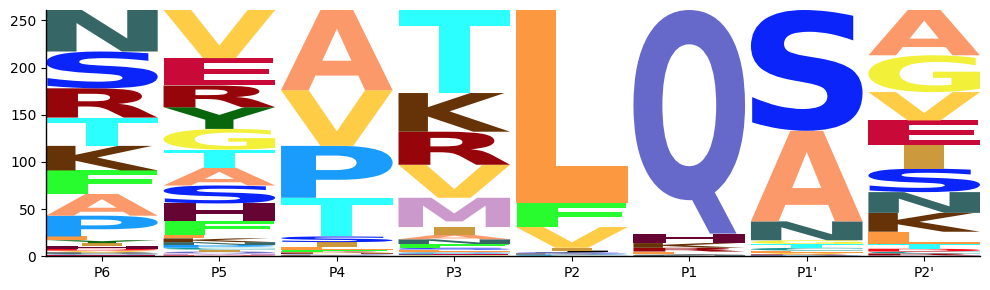

In [12]:
count_matrix = logomaker.alignment_to_matrix(nsp5_short)

_, ax = plt.subplots(figsize=(10, 3))
logo = logomaker.Logo(count_matrix,
                      ax=ax,
                      color_scheme='skylign_protein')

logo.style_spines(visible=False)
logo.style_spines(spines=['left', 'bottom'], visible=True)
logo.style_xticks(rotation=0, fmt='%d', anchor=0)
logo.ax.set_xticklabels(['P6', 'P5', 'P4', 'P3', 'P2', 'P1', "P1'", "P2'"])

plt.tight_layout()
plt.show()

/root/miniconda3/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'B' is not in color_dict. Using black.
  warnings.warn(str(Error))
/root/miniconda3/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'J' is not in color_dict. Using black.
  warnings.warn(str(Error))
/root/miniconda3/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'Z' is not in color_dict. Using black.
  warnings.warn(str(Error))


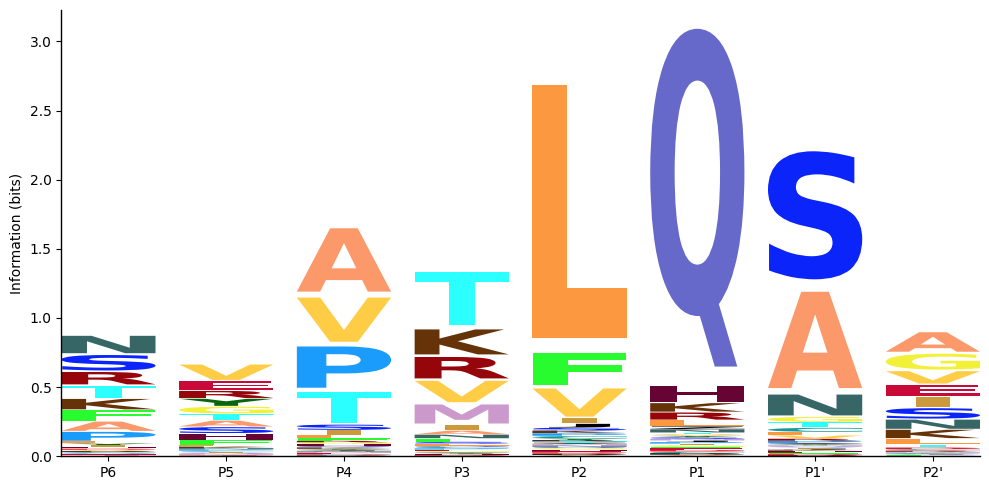

In [7]:
info_matrix = logomaker.transform_matrix(count_matrix,
                                         from_type='counts',
                                         to_type='information')

_, ax = plt.subplots(figsize=(10, 5))
logo = logomaker.Logo(info_matrix,
                      ax=ax,
                      color_scheme='skylign_protein')

logo.style_spines(visible=False)
logo.style_spines(spines=['left', 'bottom'], visible=True)


logo.ax.set_xticks(range(8))
logo.ax.set_xticklabels(['P6', 'P5', 'P4', 'P3', 'P2', 'P1', "P1'", "P2'"])

ax.set_ylabel('Information (bits)')

plt.tight_layout()
plt.show()

In [8]:
with open(f'../data/processed/nsp5_short.fasta', 'w') as fasta:
    for i, seq in enumerate(nsp5_short):
        fasta.write(f'>SARS-CoV-2_{i}\n{seq}\n')

# create dataset for EVE

## training set

sequences have been saved to `../data/processed/nsp5_short.fasta`

In [9]:
def prepare_dataset_for_eve(aa_len=8):
    with open(f'../data/processed/sars_nsp5_site_{aa_len}aa_mapping.csv', 'w') as f:
        line = f'protein_name,msa_location,theta\nnsp5,nsp5_short.fasta,0.01'
        f.write(line)

In [10]:
prepare_dataset_for_eve()

## test set

P4-P2' to P6-P2'

In [9]:
nsp5_testset_list = []
for record in SeqIO.parse(f'../data/raw/nsp5_testset.fasta', 'fasta'):
    # test set only contains P4-P2', add WT's TS
    record.seq = Seq('TS' + str(record.seq))
    nsp5_testset_list.append(record)

with open(f'../data/processed/nsp5_testset_8aa.fasta', 'w') as output_file:
    SeqIO.write(nsp5_testset_list, output_file, 'fasta')

In [10]:
with open(f'../data/processed/nsp5_testset_8aa_mapping.csv', 'w') as f:
    line = f'protein_name,msa_location,theta\nnsp5,nsp5_testset_8aa.fasta,0.01'
    f.write(line)

check whether any test set sequences are duplicated in the training set

In [11]:
train_set_seq = []
for record in SeqIO.parse('../data/processed/nsp5_short.fasta', 'fasta'):
    train_set_seq.append(str(record.seq))

n = 0
for record in SeqIO.parse(f'../data/processed/nsp5_testset_8aa.fasta', 'fasta'):
    if str(record.seq) in train_set_seq:
        n += 1
n

0